<a href="https://colab.research.google.com/github/mikakia/AdvanceML_Final_Project/blob/main/blasto_ss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import torch
from torch import nn
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import random_split, DataLoader
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


# Data Loading and EDA

## Before running:
Change shortcut to data.

For Ieva: 'content/drive/MyDrive/Data'

For Mika: '/content/drive/MyDrive/Advanced_ML/Final_Project/Data' <- It should work for both :)


## Load Data from google drive

In [3]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Change before running
ROOT_DIR = '/content/drive/MyDrive/Data'

blast_dir = os.path.join(ROOT_DIR, 'Blastocyst')
icm_dir = os.path.join(ROOT_DIR, 'GT_ICM')
te_dir = os.path.join(ROOT_DIR, 'GT_TE')
zp_dir = os.path.join(ROOT_DIR, 'GT_ZP')

Mounted at /content/drive


In [4]:
print(os.listdir('/content/drive/MyDrive/Data'))
#print(os.listdir('/content/drive/MyDrive/Advanced_ML'))

['Blastocyst', 'GT_ZP', 'GT_TE', 'GT_ICM']


## Creating a class for the data extending Dataset superclass

In [5]:
CLASS_NAMES = ['background', 'ICM', 'ZP', 'TE']


# Method to combine the masks into one
def masks_to_semantic(mask_list, background_label: int = 0):
  w, h = mask_list[0].shape
  semantic_mask = torch.full((h, w), fill_value=background_label, dtype=torch.int64)

  for class_idx, mask in enumerate(mask_list, start=1):
      semantic_mask[mask > 0] = class_idx

  return semantic_mask

# Creating Dataset class for our data
class BlastDataset(Dataset):
  MASK_NAMES = [' ICM', ' ZP', ' TE']

  def __init__(self, blast_dir, mask_dirs, size=(256, 256)):
    self.size = size
    self.image_transform = transforms.Compose([
        transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.ToTensor()
    ])
    self.mask_transform = transforms.Compose([
        transforms.Resize(size, interpolation=transforms.InterpolationMode.NEAREST)
    ])
    self.blast_dir = blast_dir
    self.mask_dirs = mask_dirs

    # Create masterlist of Blastocyst names
    self.filenames = sorted([
        f for f in os.listdir(blast_dir) if f.endswith('.BMP')
    ])



  # Returns number of images
  def __len__(self):
    return len(self.filenames)

  # Takes a blastocyst name and returns corresponding mask filename
  def _get_mask_name(self, blast_filename, mask_name):
    stem = os.path.splitext(blast_filename)[0] # Retrieves only image name
    return f"{stem}{mask_name}_Mask.bmp"

  # Fetch one sample
  def __getitem__(self, index):
    fname = self.filenames[index]
    image = self.image_transform(Image.open(os.path.join(self.blast_dir, fname)).convert('L'))

    masks = []
    for mask_name, mask_dir in zip(self.MASK_NAMES, self.mask_dirs):
      mask_fname = self._get_mask_name(fname, mask_name)
      mask = self.mask_transform(Image.open(os.path.join(mask_dir,mask_fname)).convert('L')) # Convert mask to grayscale
      masks.append(mask)

    # Convert to tensors here before passing to masks_to_semantic
    masks = [torch.from_numpy(np.array(m)).long() for m in masks]

    semantic_mask = masks_to_semantic(masks)

    return image, semantic_mask

## Explore the Data

### Check for missing values

In [7]:
# Checking if any masks are missing
dataset = BlastDataset(
    blast_dir=blast_dir,
    mask_dirs=[icm_dir, zp_dir, te_dir]
)

missing = []
for fname in dataset.filenames:
  for mask_name, mask_dir in zip(dataset.MASK_NAMES, dataset.mask_dirs):
    mask_fname = dataset._get_mask_name(fname, mask_name)
    full_path = os.path.join(mask_dir, mask_fname)
    if not os.path.exists(full_path):
      missing.append(full_path)

print(missing)

[]


### Visualizations

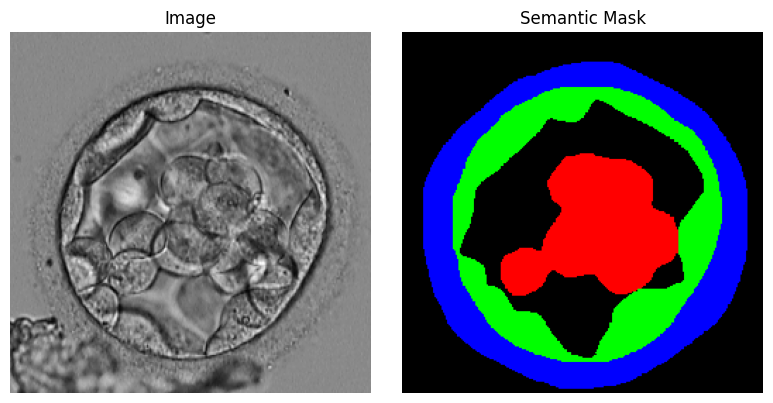

In [8]:
def semantic_mask_to_rgb(semantic_mask):
    # Define your color map: index = class label, value = (R, G, B)
    color_map = np.array([
        [0,   0,   0  ],  # 0 - background (black)
        [255, 0,   0  ],  # 1 - red
        [0,   0,   255],  # 2 - blue
        [0,   255, 0  ],  # 3 - green
    ], dtype=np.uint8)

    if hasattr(semantic_mask, "numpy"):
        semantic_mask = semantic_mask.numpy()

    return color_map[semantic_mask]  # (H, W) → (H, W, 3)


image, semantic_mask = dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(image.squeeze(), cmap='grey')
axes[0].set_title('Image')

#for i, (mask, mask_name) in enumerate(zip(masks, [' ICM', ' ZP', ' TE'])):
#  axes[i+1].imshow(mask, cmap='gray')
#  axes[i+1].set_title(f'{mask_name} Mask')

axes[1].imshow(semantic_mask_to_rgb(semantic_mask))
axes[1].set_title('Semantic Mask')
for ax in axes:
  ax.axis('off')

plt.tight_layout()
plt.show()

### Check size

In [ ]:
print("Image size:", image.shape)
print("Semantic mask size:", semantic_mask.shape)

## Functions

In [9]:
def double_conv(input_c, output_c):
  conv = nn.Sequential(
                                 nn.Conv2d(in_channels=input_c,out_channels=output_c, kernel_size=3,padding='same'),      # (2)
                                 nn.ReLU(inplace=True) ,                                                                  # (3)
                                 nn.Conv2d(in_channels=output_c,out_channels=output_c, kernel_size=3,padding='same'),     # second unpadded convolution
                                 nn.ReLU(inplace=True)  )
  return conv

# Attention
def attention(x, gating, inter_shape, layers_dict):
  # x, comes from skip connections
  # g, gating signal comes from the next lowest layer of the network
  shape_x = x.shape

  # making x the same shape as the gating signal
  theta_x = layers_dict['theta_x'](x)

  phi_g = layers_dict['phi_g'](gating)

  # concatenation (element-wise addition)
  concat_xg = phi_g + theta_x

  # attention gate

  # activation function
  act_xg = F.relu(concat_xg)

  psi = layers_dict['psi'](act_xg)

  sigmoid_xg = torch.sigmoid(psi)
  shape_sigmoid = sigmoid_xg.shape

  # upsampling
  upsample_psi = F.interpolate(sigmoid_xg,
                               size=(shape_x[2], shape_x[3]),
                               mode='bilinear',
                               align_corners=True)

  y = upsample_psi * x

  result = layers_dict['result_conv'](y)
  result_bn = layers_dict['bn'](result)

  return result_bn

In [10]:
class AttentionBlock(nn.Module):
    def __init__(self, x_channels, g_channels, inter_channels):
        super(AttentionBlock, self).__init__()

        self.theta_x = nn.Conv2d(x_channels, inter_channels, kernel_size=1, stride=2)
        self.phi_g   = nn.Conv2d(g_channels,  inter_channels, kernel_size=1)
        self.psi     = nn.Conv2d(inter_channels, 1, kernel_size=1)
        self.result_conv = nn.Conv2d(x_channels, x_channels, kernel_size=1)
        self.bn      = nn.BatchNorm2d(x_channels)

    def forward(self, x, gating):
        theta_x    = self.theta_x(x)
        phi_g      = self.phi_g(gating)
        concat_xg  = phi_g + theta_x
        act_xg     = F.relu(concat_xg)
        psi        = self.psi(act_xg)
        sigmoid_xg = torch.sigmoid(psi)

        upsample_psi = F.interpolate(sigmoid_xg,
                                     size=(x.shape[2], x.shape[3]),
                                     mode='bilinear',
                                     align_corners=True)
        y         = upsample_psi * x
        result    = self.result_conv(y)
        result_bn = self.bn(result)
        return result_bn


class UNet_Attention(nn.Module):

  def __init__(self):
    super(UNet_Attention, self).__init__()                                   # initiliazion for nn.Module
    self.max_pool_2x2 = nn.MaxPool2d(kernel_size=2,stride=2)       # (1)

    # first part Downsampling (5)
    self.down_conv_1 = double_conv(1,64)
    self.down_conv_2 = double_conv(64,128)
    self.down_conv_3 = double_conv(128,256)
    self.down_conv_4 = double_conv(256,512)
    self.down_conv_5 = double_conv(512,1024)

    #  second part Upsampling (6) transpose convolution

    # First
    self.up_trans_1 = nn.ConvTranspose2d(in_channels=1024,          # input channels from the last down_conv5 and
                                        out_channels=512,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_1 = double_conv(1024,512)


    # Second
    self.up_trans_2 = nn.ConvTranspose2d(in_channels=512,          # input channels from the last down_conv5 and
                                        out_channels=256,          # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_2 = double_conv(512,256)


    # Third
    self.up_trans_3 = nn.ConvTranspose2d(in_channels=256,           # input channels from the last down_conv5 and
                                        out_channels=128,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_3= double_conv(256,128)

    # Fourth
    self.up_trans_4 = nn.ConvTranspose2d(in_channels=128,          # input channels from the last down_conv5 and
                                        out_channels=64,           # output channels from the output of down_conv4 which is passed to the decoder
                                       kernel_size=2,stride=2)

    self.up_conv_4 = double_conv(128,64)

    # Attention blocks (x_channels, g_channels, inter_channels)
    self.attn_1 = AttentionBlock(x_channels=512,  g_channels=1024, inter_channels=256)
    self.attn_2 = AttentionBlock(x_channels=256,  g_channels=512,  inter_channels=128)
    self.attn_3 = AttentionBlock(x_channels=128,  g_channels=256,  inter_channels=64)
    self.attn_4 = AttentionBlock(x_channels=64,   g_channels=128,  inter_channels=32)

    # Output layer
    self.output = nn.Conv2d(in_channels=64,out_channels=4, kernel_size=1)  # 2d convolition with kernel size of 1

  def forward(self,image):

    # batch size, channels, height and width
    #print("\n =============ENCODER===============\n")
    # encoder layers
    x1 = self.down_conv_1(image) # output passed to the decoder
    #print("First encoder layer:", x1.size())
    x2 = self.max_pool_2x2(x1)
    x3 = self.down_conv_2(x2)    # output passed to the decoder
    x4 = self.max_pool_2x2(x3)
    x5 = self.down_conv_3(x4)    # output passed to the decoder
    x6 = self.max_pool_2x2(x5)
    x7 = self.down_conv_4(x6)    # output passed to the decoder
    #print("4th encoder layer size x7", x7.size())
    x8 = self.max_pool_2x2(x7)
    x9 = self.down_conv_5(x8)
    #print("Last encoder layer x9:",x9.size())

    # decoder layers

    #print("\n =============DECODER===============\n")
    # First
    # ----- attention first layer --------
    # x9 is the gating signal
    # x7 is the skip connection
    x7_att = self.attn_1(x7, x9)
    x = self.up_trans_1(x9)                       # x should be concatened with x7 to create the skip connections in Unet
    #print("First decoder layer x: ",x.size())
    x = self.up_conv_1(torch.cat([x,x7_att],1))
    #print(x.size())

    # Second
    # ----- attention second layer --------
    # x is the gating signal
    # x5 is the skip connection
    x5_att = self.attn_2(x5, x)
    x = self.up_trans_2(x)                       # x should be concatened with x5 to create the skip connections in Unet
    #print("Second decoder layer x: ",x.size())
    x = self.up_conv_2(torch.cat([x,x5_att],1))
    #print(x.size())

    # Third
    # ----- attention third layer --------
    # x is the gating signal
    # x3 is the skip connection
    x3_att = self.attn_3(x3, x)
    x = self.up_trans_3(x)                       # x should be concatened with x3 to create the skip connections in Unet
    #print("Third decoder layer x: ",x.size())
    x = self.up_conv_3(torch.cat([x,x3_att],1))
    #print(x.size())

    # Fourth
    # ----- attention fourth layer --------
    # x is the gating signal
    # x1 is the skip connection
    x1_att = self.attn_4(x1, x)
    x = self.up_trans_4(x)                       # x should be concatened with x1 to create the skip connections in Unet
    #print("Fourth decoder layer x: ",x.size())
    x = self.up_conv_4(torch.cat([x,x1_att],1))
    #print(x.size())

    # Output
    out = self.output(x)
    #print("Output size: ",out.size())

    return out

In [11]:
class UNet(nn.Module):

  def __init__(self):
    super(UNet, self).__init__()                                   # initiliazion for nn.Module
    self.max_pool_2x2 = nn.MaxPool2d(kernel_size=2,stride=2)       # (1)

    # first part Downsampling (5)
    self.down_conv_1 = double_conv(1,64)
    self.down_conv_2 = double_conv(64,128)
    self.down_conv_3 = double_conv(128,256)
    self.down_conv_4 = double_conv(256,512)
    self.down_conv_5 = double_conv(512,1024)

    #  second part Upsampling (6) transpose convolution

    # First
    self.up_trans_1 = nn.ConvTranspose2d(in_channels=1024,          # input channels from the last down_conv5 and
                                        out_channels=512,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_1 = double_conv(1024,512)


    # Second
    self.up_trans_2 = nn.ConvTranspose2d(in_channels=512,          # input channels from the last down_conv5 and
                                        out_channels=256,          # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_2 = double_conv(512,256)


    # Third
    self.up_trans_3 = nn.ConvTranspose2d(in_channels=256,           # input channels from the last down_conv5 and
                                        out_channels=128,           # output channels from the output of down_conv4 which is passed to the decoder
                                        kernel_size=2,stride=2)

    self.up_conv_3= double_conv(256,128)

    # Fourth
    self.up_trans_4 = nn.ConvTranspose2d(in_channels=128,          # input channels from the last down_conv5 and
                                        out_channels=64,           # output channels from the output of down_conv4 which is passed to the decoder
                                       kernel_size=2,stride=2)

    self.up_conv_4 = double_conv(128,64)

    # Output layer
    self.output = nn.Conv2d(in_channels=64,out_channels=4, kernel_size=1)  # 2d convolition with kernel size of 1

  def forward(self,image):

    # batch size, channels, height and width
    #print("\n =============ENCODER===============\n")
    # encoder layers
    x1 = self.down_conv_1(image) # output passed to the decoder
    #print("First encoder layer:", x1.size())
    x2 = self.max_pool_2x2(x1)
    x3 = self.down_conv_2(x2)    # output passed to the decoder
    x4 = self.max_pool_2x2(x3)
    x5 = self.down_conv_3(x4)    # output passed to the decoder
    x6 = self.max_pool_2x2(x5)
    x7 = self.down_conv_4(x6)    # output passed to the decoder
    #print("4th encoder layer size x7", x7.size())
    x8 = self.max_pool_2x2(x7)
    x9 = self.down_conv_5(x8)
    #print("Last encoder layer x9:",x9.size())

    # decoder layers

    #print("\n =============DECODER===============\n")
    # First
    x = self.up_trans_1(x9)                       # x should be concatened with x7 to create the skip connections in Unet
    #print("First decoder layer x: ",x.size())
    x = self.up_conv_1(torch.cat([x,x7],1))
    #print(x.size())

    # ----- attention first layer --------
    # x9 is the gating signal
    # x is the result of the skip connection

    # Second

    x = self.up_trans_2(x)                       # x should be concatened with x5 to create the skip connections in Unet
    #print("Second decoder layer x: ",x.size())
    x = self.up_conv_2(torch.cat([x,x5],1))
    #print(x.size())


    # Third

    x = self.up_trans_3(x)                       # x should be concatened with x3 to create the skip connections in Unet
    #print("Third decoder layer x: ",x.size())
    x = self.up_conv_3(torch.cat([x,x3],1))
    #print(x.size())




    # Fourth

    x = self.up_trans_4(x)                       # x should be concatened with x1 to create the skip connections in Unet
    #print("Fourth decoder layer x: ",x.size())
    x = self.up_conv_4(torch.cat([x,x1],1))
    #print(x.size())

    # Output
    out = self.output(x)
    #print("Output size: ",out.size())

    return out

/tmp/ipykernel_2340/231766585.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


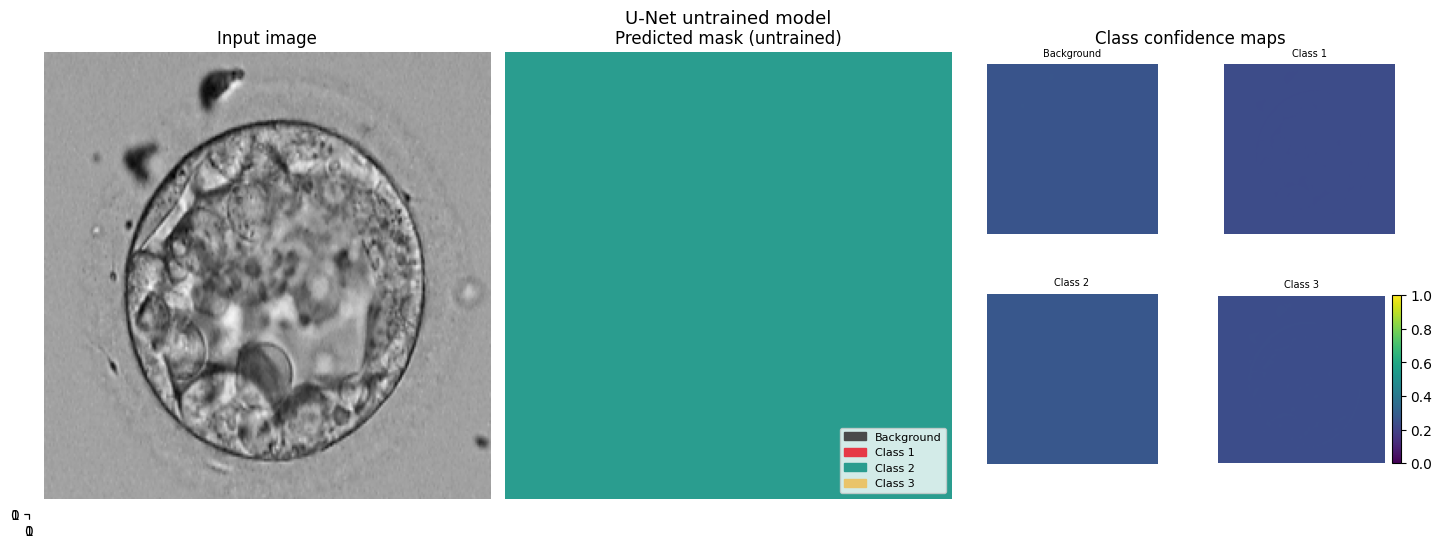

Output shape : torch.Size([1, 4, 256, 256])
Predicted classes present: [2]
Class pixel counts: {0: 0, 1: 0, 2: 65536, 3: 0}


In [12]:
import matplotlib.patches as mpatches

model = UNet()
model.eval()

image, semantic_mask = dataset[1]
batch = image.unsqueeze(0)

with torch.no_grad():
  logits = model(batch)
  probs = torch.softmax(logits, dim=1)
  pred = logits.argmax(dim=1)

pred_mask = pred.squeeze(0).numpy()

CLASS_COLORS = {
    0: ("Background", "#4a4a4a"),
    1: ("Class 1",    "#e63946"),
    2: ("Class 2",    "#2a9d8f"),
    3: ("Class 3",    "#e9c46a"),
}

# Build an RGB image from the predicted mask
h, w = pred_mask.shape
rgb = np.zeros((h, w, 3), dtype=np.uint8)
for cls_idx, (_, hex_color) in CLASS_COLORS.items():
    r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:7], 16)
    rgb[pred_mask == cls_idx] = [r, g, b]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Input image
axes[0].imshow(image.squeeze(0).numpy(), cmap="gray")
axes[0].set_title("Input image")
axes[0].axis("off")

# Predicted segmentation
axes[1].imshow(rgb)
axes[1].set_title("Predicted mask (untrained)")
axes[1].axis("off")
legend = [mpatches.Patch(color=col, label=name)
          for _, (name, col) in CLASS_COLORS.items()]
axes[1].legend(handles=legend, loc="lower right", fontsize=8)

# Per-class confidence maps
conf_grid = axes[2]
conf_grid.axis("off")
conf_grid.set_title("Class confidence maps")

inner = fig.add_axes([0, 0, 0, 0])  # dummy — we'll use GridSpec instead
fig.tight_layout()

# Replace axes[2] with a 2×2 sub-grid for the 4 confidence maps
gs = fig.add_gridspec(2, 2, left=0.68, right=0.98, top=0.9, bottom=0.1, hspace=0.35, wspace=0.3)
for cls_idx in range(4):
    ax = fig.add_subplot(gs[cls_idx // 2, cls_idx % 2])
    conf_map = probs[0, cls_idx].numpy()
    im = ax.imshow(conf_map, cmap="viridis", vmin=0, vmax=1)
    name, _ = CLASS_COLORS[cls_idx]
    ax.set_title(name, fontsize=7)
    ax.axis("off")

plt.colorbar(im, ax=fig.axes[-1], fraction=0.046, pad=0.04)
plt.suptitle("U-Net untrained model", fontsize=13, y=1.01)
plt.show()

print(f"Output shape : {logits.shape}")
print(f"Predicted classes present: {np.unique(pred_mask).tolist()}")
print(f"Class pixel counts: { {c: int((pred_mask == c).sum()) for c in range(4)} }")


In [13]:
# Metrics

class DiceLoss(nn.Module):
  # Smooth added to prevent division by zero
  def __init__(self, num_classes:int, smooth: float = 1e-6):
    super().__init__()
    self.num_classes = num_classes
    self.smooth = smooth

  def forward(self, logits, targets):
    # logits: (B, C, H, W), targets: (B, H, W) long
    probs = F.softmax(logits, dim=1) # Convert raw logits to probabilities
    targets_one_hot = F.one_hot(targets, self.num_classes) # (B, H, W, C)
    targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float() # (B, C, H, W)

    dims = (0, 2, 3) #average over batch, height, width
    intersection = (probs * targets_one_hot).sum(dims) # Element wise multiply probability with target
    cardinality = (probs + targets_one_hot).sum(dims) # Total predicted + total actual pixels per class

    dice_per_class = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
    return 1.0 - dice_per_class.mean() # Average over classes

class SegmentationLoss(nn.Module):
  # Weighted sum of CrossEntropy and Dice Loss
  def __init__(self, num_classes: int, ce_weight: float = 0.5, dice_weight: float = 0.5):
    super().__init__()
    self.ce = nn.CrossEntropyLoss()
    self.dice = DiceLoss(num_classes)
    self.ce_w = ce_weight
    self.dice_w = dice_weight

  def forward(self, logits, targets):
    return self.ce_w * self.ce(logits, targets) + self.dice_w * self.dice(logits, targets)

In [14]:
# Mean-IoU per class and overall
# preds: (B, H, W) long - predicted class indices
# targets: (B, H, W) long - ground-truth class indices
# Returns: dict with per-class IoU and mean_iou
def compute_iou(preds: torch.Tensor, targets: torch.Tensor, num_classes: int, class_names=None) -> dict:
  if class_names is None:
    class_names = [f"Class {i}" for i in range(num_classes)]

  iou_per_class = []
  for cls in range(num_classes):
    pred_mask = (preds == cls)
    target_mask = (targets == cls)
    intersection = (pred_mask & target_mask).sum().item()
    union = (pred_mask | target_mask).sum().item()
    iou = (intersection + 1e-6) / (union + 1e-6)
    iou_per_class.append(iou)

  result = {class_names[i]: v for i, v in enumerate(iou_per_class)}
  result["mean_iou"] = float(np.mean(iou_per_class))

  return result

# Training loop
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  total_loss = 0.0

  for batch_idx, (images, masks) in enumerate(loader):
    images = images.to(device, dtype=torch.float32) # (B, 1, 256, 265)
    masks = masks.to(device, dtype=torch.long) # (B, 256, 256)

    optimizer.zero_grad()
    logits = model(images)
    loss = criterion(logits, masks)
    loss.backward()

    # Gradient clipping
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    optimizer.step()
    total_loss += loss.item()

  return total_loss / len(loader)

# Validation loop
@torch.no_grad()
def validate(model, loader, criterion, device, num_classes: int, class_names=None):
  model.eval()
  total_loss = 0.0
  all_preds, all_targets = [], []

  for images, masks in loader:
    images = images.to(device, dtype=torch.float32) # (B, 1, 256, 265)
    masks = masks.to(device, dtype=torch.long) # (B, 256, 256)

    logits = model(images)
    loss = criterion(logits, masks)
    total_loss += loss.item()

    preds = logits.argmax(dim=1)
    all_preds.append(preds.cpu())
    all_targets.append(masks.cpu())

  all_preds = torch.cat(all_preds, dim=0)
  all_targets = torch.cat(all_targets, dim=0)

  metrics = compute_iou(all_preds, all_targets, num_classes, class_names)
  metrics['val_loss'] = total_loss / len(loader)
  return metrics

In [29]:
def train(
    dataset,
    *,
    num_classes: int = 4,
    class_names: list[str] = None,
    val_split: float = 0.2,
    epochs: int = 50,
    batch_size: int = 8,
    lr: float = 1e-4,
    base_filters: int = 64,
    save_path: str = 'best_attention_unet.pth',
    device: str | None = None
):
  if device is None:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
  print(f"Using device: {device}")

  # Data split
  n_val = int(len(dataset) * val_split)
  n_train = len(dataset) - n_val
  train_ds, val_ds = random_split(
      dataset, [n_train, n_val],
      generator=torch.Generator().manual_seed(42)
  )

  train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle=True, num_workers=2, pin_memory=True)
  val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

  # Model, loss, optimizer
  model = UNet_Attention().to(device)
  criterion = SegmentationLoss(num_classes).to(device)
  optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
  scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr/100)

  total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  print(f"Total number of trainable parameters: {total_params}")

  # Training loop

  best_miou = 0.0

  for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate(model, val_loader, criterion, device, num_classes, class_names=None)
    scheduler.step()

    miou = val_metrics['mean_iou']
    print(
        f"Epoch {epoch:3d}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {val_metrics['val_loss']:.4f} | "
        f"mIoU: {miou:.4f}"
    )

    # Print per-class IoU every 10 epochs
    if epoch % 10 == 0:
      for name, iou in val_metrics.items():
        if name != 'mean_iou':
          print(f"  {name}: {iou:.4f}")

    # Save best model
    if miou > best_miou:
      best_miou = miou
      torch.save({"epoch": epoch, "model_state": model.state_dict(),
                  "miou": miou}, save_path)

      print(f"New best model mIoU {miou:.4f} - saved to {save_path}")
  print(f"\nTraining complete. Best mIoU: {best_miou:.4f}")
  return model

# Inference helper, allows to run just one image or batch
@torch.no_grad()
def predict(model, image_tensor: torch.Tensor, device: str = "cpu") -> torch.Tensor:
  model.eval()
  if image_tensor.dim() == 3:
    image_tensor = image_tensor.unsqueeze(0) # Add batch dimension if one image

  image_tensor = image_tensor.to(device, dtype=torch.float32)
  logits = model(image_tensor)
  preds = logits.argmax(dim=1)
  return preds.squeeze(0) if preds.size(0) == 1 else preds

In [18]:
model = train(
    dataset,
    num_classes = 4,
    class_names = CLASS_NAMES,
    val_split = 0.2,
    epochs = 50,
    batch_size = 8,
    lr = 1e-4,
    base_filters = 64,
    save_path = 'best_unet.pth'
)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Total number of trainable parameters: 31030788


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch   1/50 | Train loss: 1.0285 | Val loss: 0.9003 | mIoU: 0.1659
New best model mIoU 0.1659 - saved to best_unet.pth
Epoch   2/50 | Train loss: 0.8830 | Val loss: 0.8653 | mIoU: 0.1659
Epoch   3/50 | Train loss: 0.8675 | Val loss: 0.8342 | mIoU: 0.1659
Epoch   4/50 | Train loss: 0.8132 | Val loss: 0.7884 | mIoU: 0.1659
Epoch   5/50 | Train loss: 0.7886 | Val loss: 0.7612 | mIoU: 0.1659
New best model mIoU 0.1659 - saved to best_unet.pth
Epoch   6/50 | Train loss: 0.7653 | Val loss: 0.7590 | mIoU: 0.1794
New best model mIoU 0.1794 - saved to best_unet.pth
Epoch   7/50 | Train loss: 0.7394 | Val loss: 0.7072 | mIoU: 0.1674
Epoch   8/50 | Train loss: 0.7176 | Val loss: 0.6692 | mIoU: 0.2649
New best model mIoU 0.2649 - saved to best_unet.pth
Epoch   9/50 | Train loss: 0.7121 | Val loss: 0.6660 | mIoU: 0.2725
New best model mIoU 0.2725 - saved to best_unet.pth
Epoch  10/50 | Train loss: 0.6354 | Val loss: 0.6352 | mIoU: 0.3361
  Class 0: 0.6112
  Class 1: 0.2787
  Class 2: 0.4244
  Clas

In [31]:
model = train(
    dataset,
    num_classes = 4,
    class_names = CLASS_NAMES,
    val_split = 0.2,
    epochs = 50,
    batch_size = 8,
    lr = 1e-4,
    base_filters = 64,
    save_path = 'best_attention_unet.pth'
)

Using device: cuda
Total number of trainable parameters: 31905512
Epoch   1/50 | Train loss: 0.9331 | Val loss: 0.9948 | mIoU: 0.1659
New best model mIoU 0.1659 - saved to best_attention_unet.pth
Epoch   2/50 | Train loss: 0.7341 | Val loss: 0.9647 | mIoU: 0.1659
Epoch   3/50 | Train loss: 0.6624 | Val loss: 0.8329 | mIoU: 0.1758
New best model mIoU 0.1758 - saved to best_attention_unet.pth
Epoch   4/50 | Train loss: 0.6266 | Val loss: 1.0672 | mIoU: 0.2049
New best model mIoU 0.2049 - saved to best_attention_unet.pth
Epoch   5/50 | Train loss: 0.5927 | Val loss: 0.8601 | mIoU: 0.2605
New best model mIoU 0.2605 - saved to best_attention_unet.pth
Epoch   6/50 | Train loss: 0.5768 | Val loss: 0.6834 | mIoU: 0.3424
New best model mIoU 0.3424 - saved to best_attention_unet.pth
Epoch   7/50 | Train loss: 0.5633 | Val loss: 1.0252 | mIoU: 0.2412
Epoch   8/50 | Train loss: 0.5738 | Val loss: 2.2588 | mIoU: 0.1897
Epoch   9/50 | Train loss: 0.5310 | Val loss: 0.6431 | mIoU: 0.3833
New best mod

In [37]:
# 1. Rebuild the model architecture (must match what you trained)
model = UNet()

# 2. Load the saved weights
checkpoint = torch.load("best_unet.pth", map_location="cpu")
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']} with mIoU {checkpoint['miou']:.4f}")

# 3. Grab an image and predict
image, mask = dataset[0]              # or load your own image tensor
pred_mask = predict(model, image)     # (256, 256) class indices

print(pred_mask.shape)
print(pred_mask.unique())             # which classes were predicted

Loaded checkpoint from epoch 49 with mIoU 0.6367
torch.Size([256, 256])
tensor([0, 1, 2, 3])


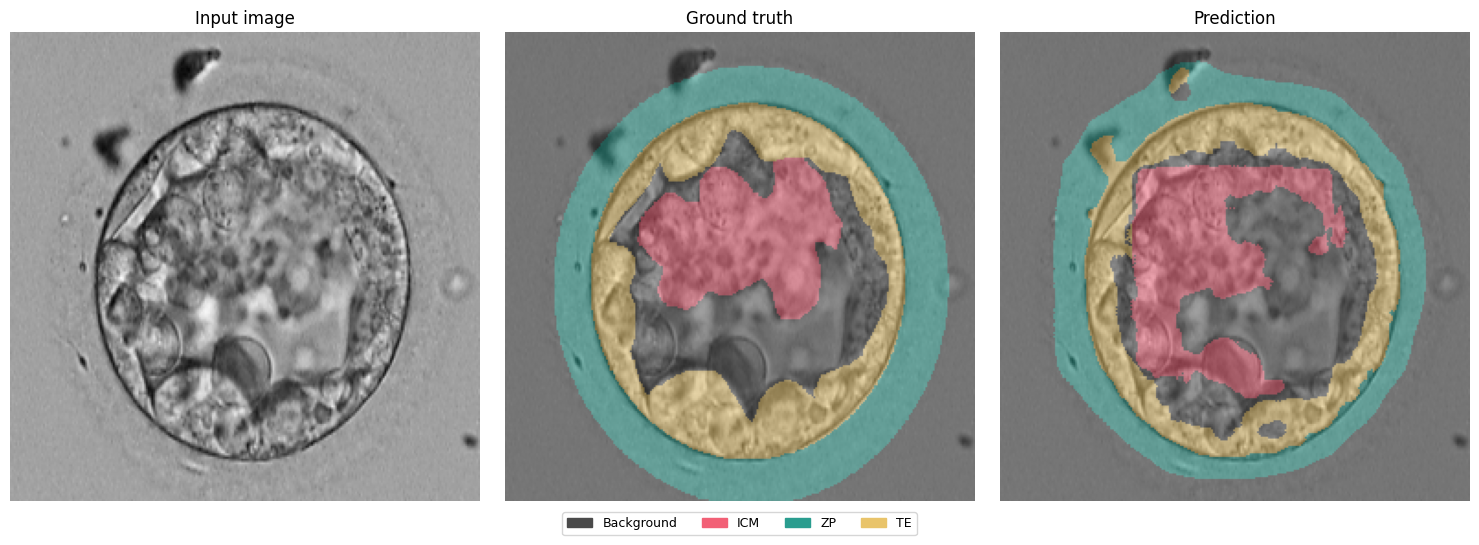

In [40]:
CLASS_COLORS = {
    0: ("Background", "#4a4a4a"),
    1: ("ICM",     "#f26076"),
    2: ("ZP",      "#2a9d8f"),
    3: ("TE",     "#e9c46a"),
}

def visualize_prediction(image, pred_mask, gt_mask=None, class_colors=CLASS_COLORS, alpha=0.5):
    """
    Args:
        image:     (1, 256, 256) float tensor
        pred_mask: (256, 256)    long tensor  — from predict()
        gt_mask:   (256, 256)    long tensor  — class indices
                   (4, 256, 256) float tensor — one-hot, converted automatically
        alpha:     overlay transparency (0=invisible, 1=opaque)
    """

    if gt_mask is not None and gt_mask.dim() == 3:
        gt_mask = gt_mask.argmax(dim=0)

    # Convert grayscale image to RGB for overlay
    img_np = image.squeeze(0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())  # normalise to [0,1]
    img_rgb = np.stack([img_np] * 3, axis=-1)                         # (H, W, 3)

    def mask_to_rgb(mask_np):
        h, w = mask_np.shape
        rgb = np.zeros((h, w, 3), dtype=np.float32)
        for cls_idx, (_, hex_color) in class_colors.items():
            r = int(hex_color[1:3], 16) / 255.0
            g = int(hex_color[3:5], 16) / 255.0
            b = int(hex_color[5:7], 16) / 255.0
            rgb[mask_np == cls_idx] = [r, g, b]
        return rgb

    def overlay(img, mask_np):
        """Blend image and coloured mask: out = (1-alpha)*img + alpha*mask"""
        mask_rgb = mask_to_rgb(mask_np)
        return np.clip((1 - alpha) * img + alpha * mask_rgb, 0, 1)

    pred_np = pred_mask.cpu().numpy()
    n_cols  = 3 if gt_mask is not None else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

    # Input image
    axes[0].imshow(img_rgb)
    axes[0].set_title("Input image")
    axes[0].axis("off")

    # Ground truth overlay
    if gt_mask is not None:
        gt_np = gt_mask.cpu().numpy()
        axes[1].imshow(overlay(img_rgb, gt_np))
        axes[1].set_title("Ground truth")
        axes[1].axis("off")

    # Prediction overlay
    ax_pred = axes[2] if gt_mask is not None else axes[1]
    ax_pred.imshow(overlay(img_rgb, pred_np))
    ax_pred.set_title("Prediction")
    ax_pred.axis("off")

    # Highlight disagreements in red on top of the prediction overlay
    # if gt_mask is not None:
    #     wrong = (pred_np != gt_np).astype(np.uint8) * 255
    #     error_overlay = np.zeros((*pred_np.shape, 4), dtype=np.uint8)
    #     error_overlay[..., 0] = wrong   # red channel
    #     error_overlay[..., 3] = wrong   # alpha channel
    #     ax_pred.imshow(error_overlay, alpha=0.4)
    #     ax_pred.set_title("Prediction (red = wrong)")

    legend = [mpatches.Patch(color=col, label=name)
              for _, (name, col) in class_colors.items()]
    fig.legend(handles=legend, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.05), fontsize=9)

    plt.tight_layout()
    plt.show()


# ── Usage ─────────────────────────────────────────────────────────────────────
image, gt_mask = dataset[1]
pred_mask = predict(model, image)
visualize_prediction(image, pred_mask, gt_mask)